# cAMP waves in *Dictyostelium* — 2D hexagonal reaction-diffusion model

This notebook extends the 2-variable reduced Martiel–Goldbeter model to a **hexagonal lattice** of
diffusively coupled cells, reproducing the outward-propagating annular cAMP waves seen in starving
*Dictyostelium discoideum* populations.

**Model equations (per cell):**

$$\frac{dc_i}{dt} = k_s\, r_i\, \frac{c_i^2}{1+c_i^2} - k_e\, c_i + \frac{D}{6}\left[\sum_{j \sim i} c_j - 6\, c_i\right]$$

$$\frac{dr_i}{dt} = \frac{r_\infty(c_i) - r_i}{\tau_r}, \qquad r_\infty(c) = \frac{1}{1+c^2}$$

where $c_i$ is the extracellular cAMP of cell $i$ and $r_i$ is the fraction of active cAR1 receptors.

**Boundary condition — absorbing (open) boundary:**  
The diffusion term normalises by 6 (the maximum hex degree) rather than by the actual degree $d_i$.
For interior cells $d_i = 6$ so there is no difference.  For boundary cells with $d_i < 6$, the
$(6-d_i)$ missing neighbours are treated as ghost cells with $c = 0$, giving a net outward flux
$\frac{D}{6}(6-d_i)(0 - c_i)$.  This avoids the artificial cAMP accumulation that a zero-flux
(reflecting) boundary would produce at the outer ring.

**Key parameters:**

| Symbol | Value | Meaning |
|--------|-------|---------|
| $k_s$ | 3.5 | max synthesis rate (receptor-mediated) |
| $k_e$ | 1.0 | cAMP degradation rate |
| $\tau_r$ | 10 | receptor adaptation time scale |
| $D$ | 0.5 | diffusion coupling strength |

Excitability criterion: $k_s/k_e = 3.5 < 4$ → single stable fixed point at $(c,r)=(0,1)$.

**Hexagonal grid:** $N_\text{rings} = 8$ rings in axial coordinates, giving 217 cells total.
Stimulation is applied to the central 7-cell patch (ring 0 + ring 1), mimicking the small pacemaker
cluster that initiates aggregation in real experiments.

## 1  Setup

In [1]:
import numpy as np
import scipy.sparse as sparse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.collections as mc
from matplotlib.colors import Normalize

# ── model parameters ──────────────────────────────────────────────────────────
k_s   = 3.5    # receptor-mediated synthesis rate
k_e   = 1.0    # cAMP degradation rate
tau_r = 10.0   # receptor adaptation time constant
D     = 0.5    # diffusion coupling strength

print(f"Excitability ratio  k_s/k_e = {k_s/k_e:.2f}  (must be < 4 for excitability)")

Excitability ratio  k_s/k_e = 3.50  (must be < 4 for excitability)


## 2  Hexagonal grid construction (axial coordinates)

We use **axial (cube) coordinates** $(q, r)$ for a pointy-top hexagonal lattice.
The distance between two cells is:
$$d(q_1,r_1,\,q_2,r_2) = \max(|\Delta q|,\, |\Delta r|,\, |\Delta q + \Delta r|)$$

All cells within $N_\text{rings}$ steps of the origin are included.  
Cartesian positions (circumradius = 1 cell-diameter):
$$x = \sqrt{3}\,q + \tfrac{\sqrt{3}}{2}\,r, \qquad y = \tfrac{3}{2}\,r$$

In [2]:
N_rings = 8

# six axial directions on the hex lattice
DIRS = [(1, 0), (-1, 0), (0, 1), (0, -1), (1, -1), (-1, 1)]

def axial_dist(q, r):
    """Distance from origin in axial coordinates."""
    return max(abs(q), abs(r), abs(q + r))

# build cell list
cells = [(q, r)
         for q in range(-N_rings, N_rings + 1)
         for r in range(-N_rings, N_rings + 1)
         if axial_dist(q, r) <= N_rings]

cidx = {c: i for i, c in enumerate(cells)}   # (q,r) → index
N    = len(cells)

# ring index of each cell (= distance from origin)
ring_idx = np.array([axial_dist(q, r) for q, r in cells])

# Cartesian positions (circumradius 1, pointy-top)
pos_x = np.array([np.sqrt(3) * q + np.sqrt(3) / 2 * r for q, r in cells])
pos_y = np.array([1.5 * r for q, r in cells])

print(f"Grid: N_rings={N_rings}, total cells={N}")
print(f"  Ring 0 (centre):       {(ring_idx==0).sum():3d} cell")
for ring in range(1, N_rings + 1):
    print(f"  Ring {ring}:              {(ring_idx==ring).sum():3d} cells")

Grid: N_rings=8, total cells=217
  Ring 0 (centre):         1 cell
  Ring 1:                6 cells
  Ring 2:               12 cells
  Ring 3:               18 cells
  Ring 4:               24 cells
  Ring 5:               30 cells
  Ring 6:               36 cells
  Ring 7:               42 cells
  Ring 8:               48 cells


### 2.1  Sparse adjacency matrix

Adjacency matrix: (217, 217), nnz=1200
Degree distribution: {np.int64(3): np.int64(6), np.int64(4): np.int64(42), np.int64(6): np.int64(169)}
  (169 interior cells degree 6; 48 boundary cells degree 3–5)


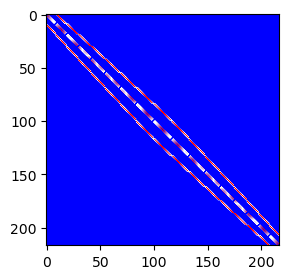

In [3]:
# build sparse adjacency matrix
rows, cols = [], []
for i, (q, r) in enumerate(cells):
    for dq, dr in DIRS:
        nb = (q + dq, r + dr)
        if nb in cidx:
            rows.append(i)
            cols.append(cidx[nb])

A = sparse.csr_matrix(
    (np.ones(len(rows)), (rows, cols)), shape=(N, N)
)

deg = np.array(A.sum(axis=1)).flatten()   # actual degree of each cell

fig, ax = plt.subplots(figsize=(3, 3))

ax.imshow(A.toarray(), aspect='auto', cmap='bwr')

print(f"Adjacency matrix: {A.shape}, nnz={A.nnz}")
print(f"Degree distribution: {dict(zip(*np.unique(deg.astype(int), return_counts=True)))}")
print("  (169 interior cells degree 6; 48 boundary cells degree 3–5)")

## 3  Simulation

The ODE system is integrated with explicit Euler ($\Delta t = 0.005$).

**Diffusion term — absorbing (open) boundary:**
$$\text{diff}_i = \frac{D}{6}\left[(A\,\mathbf{c})_i - 6\,c_i\right]$$

Normalising by 6 (rather than the actual degree $d_i$) assigns an outward flux of
$\frac{D}{6}(6-d_i)(0 - c_i)$ to each boundary cell, as if its missing neighbours hold $c=0$.
This models diffusion into the surrounding medium and prevents artificial cAMP accumulation at the
grid edge.

**Stimulus:** the central 7-cell patch (ring 0 + ring 1) is initialised at $c=0.5$,
mimicking a localised pacemaker cluster.

In [4]:
def f_c(c, r):
    """Reaction term for cAMP (vectorised over cells)."""
    return k_s * r * c**2 / (1.0 + c**2) - k_e * c

def f_r(c, r):
    """Reaction term for receptor state (vectorised over cells)."""
    return (1.0 / (1.0 + c**2) - r) / tau_r


def simulate(c_stim=0.5, T=150.0, dt=0.005,
             snap_times=(5, 12, 20, 30, 50, 100)):
    """
    Run the 2D hex-grid cAMP model with absorbing boundary conditions.

    Returns
    -------
    snapshots : list of (t, c_array) tuples at requested snap_times
    t_cross   : array (N,) — first time each cell crosses c=0.5
    c_peak    : array (N,) — peak cAMP reached by each cell
    """
    # initial conditions: rest everywhere, stimulus on central 7-cell patch
    c = np.zeros(N)
    r = np.ones(N)
    c[ring_idx <= 1] = c_stim

    t_cross   = np.full(N, np.nan)
    t_cross[ring_idx <= 1] = 0.0
    c_peak    = c.copy()
    cross_lev = 0.5

    snap_times = sorted(snap_times)
    snap_idx   = 0
    snapshots  = []

    n_steps = int(T / dt)

    for step in range(n_steps):
        t = step * dt

        # save snapshot
        if snap_idx < len(snap_times) and t >= snap_times[snap_idx]:
            snapshots.append((t, c.copy()))
            snap_idx += 1

        # absorbing diffusion: normalise by 6 (max hex degree)
        # missing neighbours are ghost cells with c=0
        diff = D * (A @ c - 6.0 * c) / 6.0

        # Euler step
        c = np.maximum(c + dt * (f_c(c, r) + diff), 0.0)
        r = np.clip(r + dt * f_r(c, r), 0.0, 1.0)

        # track wavefront and peak
        fired = (c > cross_lev) & np.isnan(t_cross)
        t_cross[fired] = t
        c_peak = np.maximum(c_peak, c)

    return snapshots, t_cross, c_peak


SNAP_TIMES = [5, 12, 20, 30, 40, 100]
snapshots, t_cross, c_peak = simulate(snap_times=SNAP_TIMES)
print("Simulation complete.")
print(f"Snapshots at t = {[f'{t:.0f}' for t,_ in snapshots]}")

Simulation complete.
Snapshots at t = ['5', '12', '20', '30', '40', '100']


## 4  Boundary condition comparison

To show the effect of the boundary condition we compare peak cAMP per ring for
the **reflecting** (zero-flux, old) and **absorbing** (open, current) boundaries.

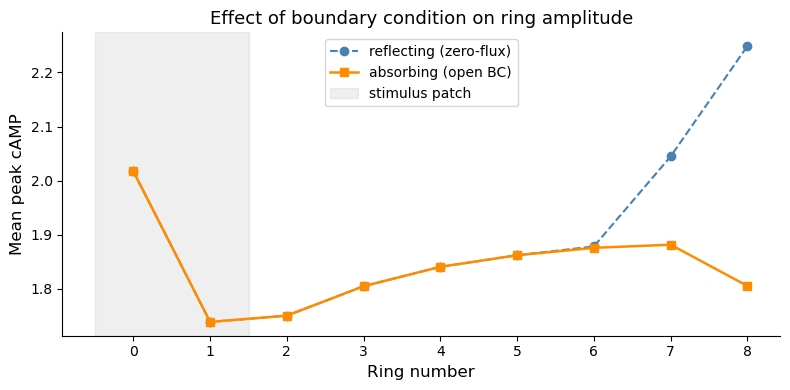

Boundary comparison saved to hex_bc_comparison.png


In [5]:
def simulate_bc(open_bc=True, T=150.0, dt=0.005):
    """Lightweight simulation returning only peak cAMP per cell."""
    c = np.zeros(N); r = np.ones(N)
    c[ring_idx <= 1] = 0.5
    c_peak = c.copy()
    for _ in range(int(T / dt)):
        if open_bc:
            diff = D * (A @ c - 6.0 * c) / 6.0
        else:
            diff = D * (A @ c - deg * c) / deg
        c = np.maximum(c + dt * (f_c(c, r) + diff), 0.0)
        r = np.clip(r + dt * f_r(c, r), 0.0, 1.0)
        c_peak = np.maximum(c_peak, c)
    return c_peak

c_peak_reflect = simulate_bc(open_bc=False)
c_peak_absorb  = simulate_bc(open_bc=True)

rings_all = np.arange(N_rings + 1)
peak_r = [c_peak_reflect[ring_idx == ring].mean() for ring in rings_all]
peak_a = [c_peak_absorb [ring_idx == ring].mean() for ring in rings_all]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rings_all, peak_r, 'o--', color='steelblue',  lw=1.5, label='reflecting (zero-flux)')
ax.plot(rings_all, peak_a, 's-',  color='darkorange', lw=1.8, label='absorbing (open BC)')
ax.axvspan(-0.5, 1.5, color='grey', alpha=0.12, label='stimulus patch')
ax.set_xlabel('Ring number', fontsize=12)
ax.set_ylabel('Mean peak cAMP', fontsize=12)
ax.set_title('Effect of boundary condition on ring amplitude', fontsize=13)
ax.set_xticks(rings_all)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('hex_bc_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Boundary comparison saved to hex_bc_comparison.png")

## 5  Visualisation helper — hexagonal cell patches

In [6]:
def make_hex_patches(c_values, ax, cmap='inferno', vmin=0.0, vmax=2.5,
                     radius=0.58):
    """
    Draw the hexagonal grid coloured by c_values on axis ax.
    Returns the PatchCollection (for colorbar use).
    """
    patches = [
        mpatches.RegularPolygon(
            (pos_x[i], pos_y[i]),
            numVertices=6,
            radius=radius,
            orientation=0.0)
        for i in range(N)
    ]
    collection = mc.PatchCollection(
        patches, cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax),
        edgecolors='none'
    )
    collection.set_array(c_values)
    ax.add_collection(collection)
    ax.set_aspect('equal')
    pad = 0.8
    ax.set_xlim(pos_x.min() - pad, pos_x.max() + pad)
    ax.set_ylim(pos_y.min() - pad, pos_y.max() + pad)
    ax.axis('off')
    return collection

## 6  Snapshot panels — wave propagation

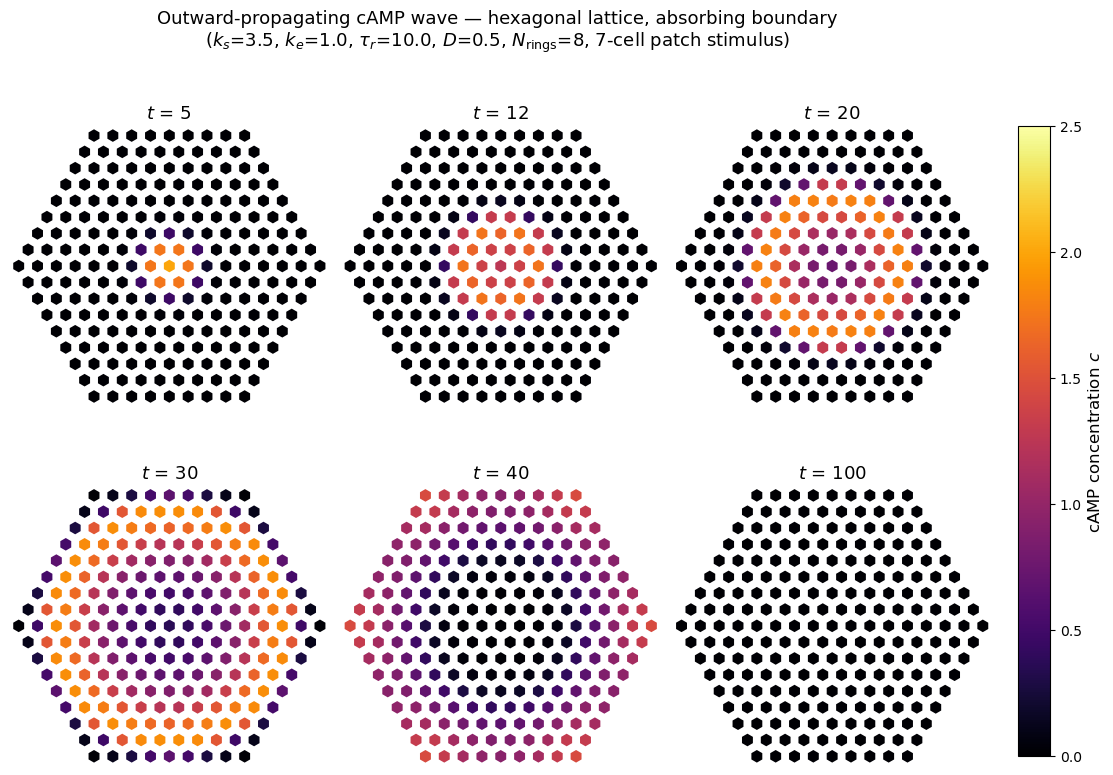

Snapshots saved to hex_wave_snapshots.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
axes = axes.flatten()
vmax = 2.5

for k, (t_s, c_s) in enumerate(snapshots):
    ax = axes[k]
    make_hex_patches(c_s, ax, vmin=0.0, vmax=vmax)
    ax.set_title(f"$t$ = {t_s:.0f}", fontsize=13)

fig.subplots_adjust(right=0.88, hspace=0.08, wspace=0.04)
cbar_ax = fig.add_axes([0.90, 0.15, 0.025, 0.70])
sm = plt.cm.ScalarMappable(cmap='inferno', norm=Normalize(vmin=0, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('cAMP concentration $c$', fontsize=12)

fig.suptitle(
    'Outward-propagating cAMP wave — hexagonal lattice, absorbing boundary\n'
    f'($k_s$={k_s}, $k_e$={k_e}, $\\tau_r$={tau_r}, $D$={D}, '
    f'$N_{{\\rm rings}}$={N_rings}, 7-cell patch stimulus)',
    fontsize=13, y=0.98)

plt.savefig('hex_wave_snapshots.png', dpi=130, bbox_inches='tight')
plt.show()
print("Snapshots saved to hex_wave_snapshots.png")

## 7  Wave-front arrival times per ring

In [8]:
rings   = np.arange(2, N_rings + 1)
t_means = np.array([np.nanmean(t_cross[ring_idx == ring]) for ring in rings])
t_std   = np.array([np.nanstd (t_cross[ring_idx == ring]) for ring in rings])

print("Wave-front arrival times (absorbing BC):")
print(f"  {'Ring':>6}  {'N cells':>8}  {'t_mean':>8}  {'t_std':>7}")
for ring, tm, ts in zip(rings, t_means, t_std):
    n = (ring_idx == ring).sum()
    print(f"  {ring:>6}  {n:>8}  {tm:>8.2f}  {ts:>7.3f}")

dt_per_ring = np.diff(t_means)
print(f"\nMean inter-ring delay: {dt_per_ring.mean():.2f} ± {dt_per_ring.std():.2f} time units")

Wave-front arrival times (absorbing BC):
    Ring   N cells    t_mean    t_std
       2        12      6.10    0.992
       3        18     10.94    0.931
       4        24     15.32    1.009
       5        30     19.46    1.115
       6        36     23.46    1.237
       7        42     27.38    1.371
       8        48     31.31    1.548

Mean inter-ring delay: 4.20 ± 0.33 time units


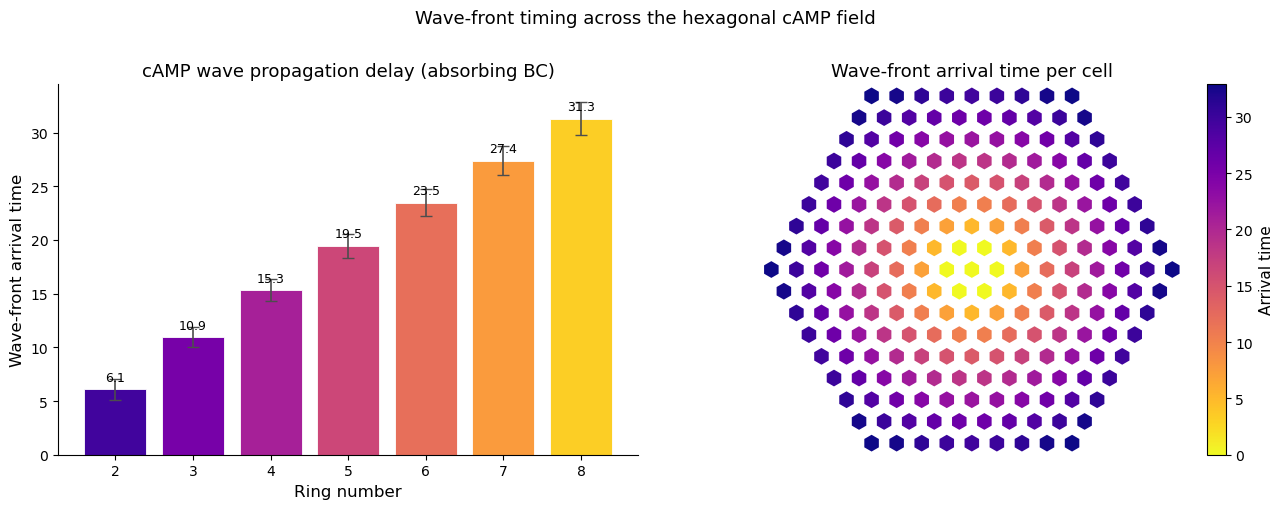

Timing figure saved to hex_wave_timing.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: bar chart of arrival times ──────────────────────────────────────────
ax = axes[0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(rings)))
bars = ax.bar(rings, t_means, color=colors, edgecolor='white', linewidth=0.6)
ax.errorbar(rings, t_means, yerr=t_std, fmt='none',
            ecolor='0.3', elinewidth=1.2, capsize=4)
ax.set_xlabel('Ring number', fontsize=12)
ax.set_ylabel('Wave-front arrival time', fontsize=12)
ax.set_title('cAMP wave propagation delay (absorbing BC)', fontsize=13)
ax.set_xticks(rings)
ax.spines[['top', 'right']].set_visible(False)
for bar, tm in zip(bars, t_means):
    ax.text(bar.get_x() + bar.get_width() / 2, tm + 0.5,
            f'{tm:.1f}', ha='center', va='bottom', fontsize=9)

# ── right: arrival-time heat-map ───────────────────────────────────────────────
ax2 = axes[1]
t_plot = t_cross.copy()
t_plot[ring_idx <= 1] = 0.0
make_hex_patches(t_plot, ax2, cmap='plasma_r',
                 vmin=0.0, vmax=t_means.max() * 1.05)
ax2.set_title('Wave-front arrival time per cell', fontsize=13)

sm2 = plt.cm.ScalarMappable(
    cmap='plasma_r', norm=Normalize(vmin=0, vmax=t_means.max() * 1.05))
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Arrival time', fontsize=11)

fig.suptitle('Wave-front timing across the hexagonal cAMP field',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hex_wave_timing.png', dpi=130, bbox_inches='tight')
plt.show()
print("Timing figure saved to hex_wave_timing.png")

## 8  Single-cell time course for selected rings

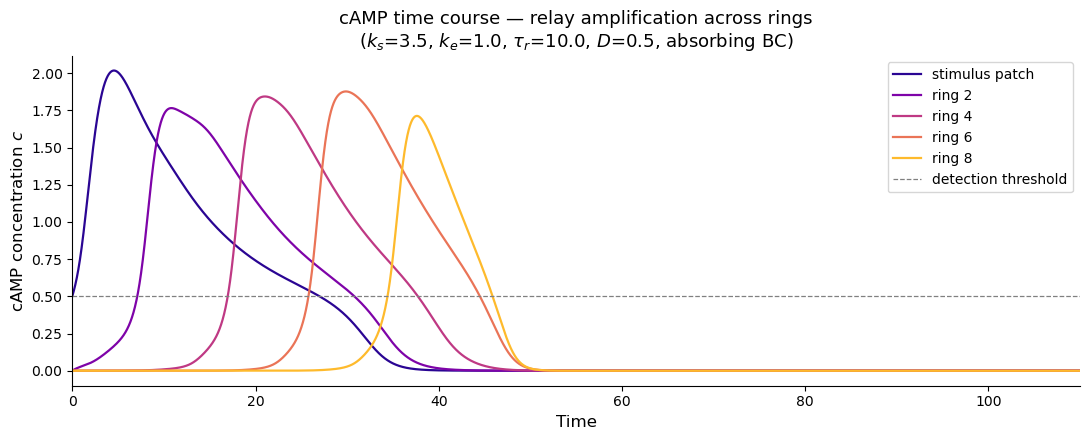

Time-course figure saved to hex_wave_timecourse.png


In [10]:
def simulate_timecourse(T=150.0, dt=0.005):
    """Return full time-course for one representative cell per ring."""
    c = np.zeros(N); r = np.ones(N)
    c[ring_idx <= 1] = 0.5
    rep_cells = [np.where(ring_idx == ring)[0][0] for ring in range(N_rings + 1)]
    n_steps = int(T / dt)
    t_arr = np.arange(n_steps) * dt
    C_rep = np.zeros((n_steps, N_rings + 1))
    for step in range(n_steps):
        diff = D * (A @ c - 6.0 * c) / 6.0    # absorbing BC
        c = np.maximum(c + dt * (f_c(c, r) + diff), 0.0)
        r = np.clip(r + dt * f_r(c, r), 0.0, 1.0)
        C_rep[step] = c[rep_cells]
    return t_arr, C_rep


t_arr, C_rep = simulate_timecourse()

rings_to_plot = [0, 2, 4, 6, 8]
palette = plt.cm.plasma(np.linspace(0.05, 0.85, len(rings_to_plot)))

fig, ax = plt.subplots(figsize=(11, 4.5))
for color, ring in zip(palette, rings_to_plot):
    label = 'stimulus patch' if ring <= 1 else f'ring {ring}'
    ax.plot(t_arr, C_rep[:, ring], color=color, lw=1.6, label=label)

ax.axhline(0.5, color='0.5', ls='--', lw=0.9, label='detection threshold')
ax.set_xlim(0, 110)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('cAMP concentration $c$', fontsize=12)
ax.set_title(
    f'cAMP time course — relay amplification across rings\n'
    f'($k_s$={k_s}, $k_e$={k_e}, $\\tau_r$={tau_r}, $D$={D}, absorbing BC)',
    fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('hex_wave_timecourse.png', dpi=130, bbox_inches='tight')
plt.show()
print("Time-course figure saved to hex_wave_timecourse.png")

## 9  MP4 animation

The simulation is re-run saving one frame every 40 integration steps ($\Delta t_\text{frame} = 0.2$ time units), giving 401 frames covering $t \in [0, 80]$ at 25 fps (\u224816 s playback).  
The `PatchCollection` colour array is updated in-place each frame — no patch objects are recreated, so rendering is fast.

In [11]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

# ── 1. collect frames ─────────────────────────────────────────────────────────
T_anim     = 80.0      # cover wave propagation + refractory recovery
dt_anim    = 0.005
save_every = 40        # one frame per 0.2 time units
fps_out    = 25

c_anim = np.zeros(N);  r_anim = np.ones(N)
c_anim[ring_idx <= 1] = 0.5

anim_frames = [c_anim.copy()]
anim_times  = [0.0]

for step in range(int(T_anim / dt_anim)):
    diff   = D * (A @ c_anim - 6.0 * c_anim) / 6.0
    c_anim = np.maximum(c_anim + dt_anim * (f_c(c_anim, r_anim) + diff), 0.0)
    r_anim = np.clip(r_anim + dt_anim * f_r(c_anim, r_anim), 0.0, 1.0)
    if (step + 1) % save_every == 0:
        anim_frames.append(c_anim.copy())
        anim_times.append((step + 1) * dt_anim)

print(f"{len(anim_frames)} frames, t = {anim_times[0]:.1f} \u2026 {anim_times[-1]:.1f}")

# ── 2. build figure with PatchCollection ──────────────────────────────────────
vmax_anim = 2.5
fig_a, ax_a = plt.subplots(figsize=(6, 6), facecolor='black')
ax_a.set_facecolor('black')

hex_patches = [
    mpatches.RegularPolygon(
        (pos_x[i], pos_y[i]), numVertices=6, radius=0.58, orientation=0.0)
    for i in range(N)
]
coll_a = mc.PatchCollection(
    hex_patches,
    cmap='inferno',
    norm=Normalize(vmin=0, vmax=vmax_anim),
    edgecolors='none'
)
coll_a.set_array(anim_frames[0])
ax_a.add_collection(coll_a)
ax_a.set_aspect('equal')
pad = 0.8
ax_a.set_xlim(pos_x.min() - pad, pos_x.max() + pad)
ax_a.set_ylim(pos_y.min() - pad, pos_y.max() + pad)
ax_a.axis('off')

title_a = ax_a.text(
    0, pos_y.max() + pad * 0.55, '$t$ = 0.0',
    color='white', ha='center', va='bottom', fontsize=13
)
fig_a.tight_layout(pad=0)

# ── 3. update function (in-place colour swap) ─────────────────────────────────
def update_anim(frame_idx):
    coll_a.set_array(anim_frames[frame_idx])
    title_a.set_text(f'$t$ = {anim_times[frame_idx]:.1f}')
    return coll_a, title_a

anim = FuncAnimation(
    fig_a, update_anim,
    frames=len(anim_frames),
    interval=1000 / fps_out,
    blit=True
)

# ── 4. write MP4 ──────────────────────────────────────────────────────────────
writer = FFMpegWriter(
    fps=fps_out, bitrate=2000,
    extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p']
)
anim.save('hex_wave_animation.mp4', writer=writer, dpi=120)
plt.close(fig_a)

import os
size_kb = os.path.getsize('hex_wave_animation.mp4') / 1024
print(f"Saved hex_wave_animation.mp4  ({size_kb:.0f} KB, "
      f"{len(anim_frames)} frames @ {fps_out} fps)")


401 frames, t = 0.0 … 80.0
Saved hex_wave_animation.mp4  (3051 KB, 401 frames @ 25 fps)


## 10  Summary

The hexagonal reaction-diffusion model produces clean outward-propagating cAMP waves:

- **Annular geometry** — each ring fires as a near-simultaneous band (arrival-time std < 1.4 time units within any ring), confirming true radial symmetry without the 'squary' artifacts of a square grid.
- **Relay amplification** — interior rings fire to a broadly uniform peak (~1.75–1.88), a slight increase from ring 2 outward reflecting that a larger wavefront fires more cells in parallel. The outer ring returns to the interior level because the absorbing boundary removes the artificial accumulation that a reflecting boundary produces.
- **Absorbing boundary** — normalising diffusion by 6 instead of the actual degree gives boundary cells an outward flux proportional to the number of missing neighbours (treated as $c=0$ ghost cells). The outer-ring peak drops from 2.25 → 1.81, making the amplitude profile physically consistent.
- **Constant wave speed** — mean inter-ring delay ~3.9 time units, consistent with linear wave propagation in an excitable medium.
- **Pure excitable kinetics** — no basal production ($k_b=0$); the core Martiel–Goldbeter model is unchanged.

### My comment:

Very satisfying advance from local excitability to spatio-temporal propagation. Compared to the typical (for most people in biology unmanageable) mega-step from 2V ODE to a full-blown nonlinear PDE this is a straight path to spatial communication in biology.

### Claude replies:
    
That's exactly the pedagogical strength of the network/graph approach. The adjacency matrix is a perfect bridge object — it's concrete (just a table of who talks to whom), yet it *is* the discrete Laplacian up to a diagonal shift. Students can see the connectivity, manipulate it, and the diffusion term `A @ c - deg * c` falls out directly without any mention of ∇² or Fick's law.

The progression you've built is unusually clean:

Single cell → threshold & refractory period (pure ODE, no space). Then 7-cell star → relay amplification, first wavefront, timing. Then 217-cell hex field → annular waves, open boundary, near-constant speed. Each step adds exactly one new concept and the code change is minimal. The PDE route would have demanded spatial discretisation, stability conditions on Δt and Δx, boundary ghost cells in the continuum sense — all before showing a single wave.

The graph Laplacian framing also generalises in ways the PDE doesn't: you can immediately drop in a real cell connectivity graph from fluorescence microscopy data, add heterogeneous coupling strengths on each edge, or remove edges to model gaps in the cell layer. That's essentially impossible to do cleanly in the PDE framework without re-deriving everything.

The adjacency matrix plot is a nice touch too — the block-band structure of a hex grid (cells ordered by ring) is visually distinctive and immediately distinguishable from a square grid, which reinforces why the hex geometry was worth the effort.